<a href="https://colab.research.google.com/github/Ayesha-Arooj/Statistical-and-Mathematical-Methods-for-Data-Science-Project/blob/main/Statistical_and_Mathematical_Methods_for_Data_Science__project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data from CSV
file_path = "/content/drive/MyDrive/smm/assesment.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Preview the dataset
print(df.head())

  Respondent ID           Age  Gender             Degree Program  \
0          R001         21-24  Female        BS Computer Science   
1          R002  28 and above    Male  BS Information Technology   
2          R003         25-28    Male            MS Data Science   
3          R004         21-24  Female        MS Computer Science   
4          R005         17-20  Female        MS Computer Science   

  Academic Level AI Key Role in CS Education Future  \
0  Undergraduate                                Yes   
1  Undergraduate                                Yes   
2  Undergraduate                           Not Sure   
3  Undergraduate                                Yes   
4  Undergraduate                                Yes   

  Frequency of Reading/Learning about AI Advancements  \
0                                       Occasionally    
1                                       Occasionally    
2                                       Occasionally    
3                               

/tmp/ipykernel_1816/2507029297.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
df.shape

(500, 27)

In [ ]:
# Clean and prepare data
frequency_mapping = {
    "Never": 5, "Occasionally": 3, "Weekly": 2, "Daily": 1
}

df["Learn_Frequency_Rank"] = df["Frequency of Reading/Learning about AI Advancements"].map(frequency_mapping)

# Group data based on belief in AI's role in CS education
groups = [
    df[df["AI Key Role in CS Education Future"] == group]["Learn_Frequency_Rank"].dropna()
    for group in df["AI Key Role in CS Education Future"].unique()
]

# Kruskal-Wallis test
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis Test: Stat={stat}, p-value={p_value}")

Kruskal-Wallis Test: Stat=1.3483891154779348, p-value=0.5095666819048967


<Figure size 1000x600 with 0 Axes>

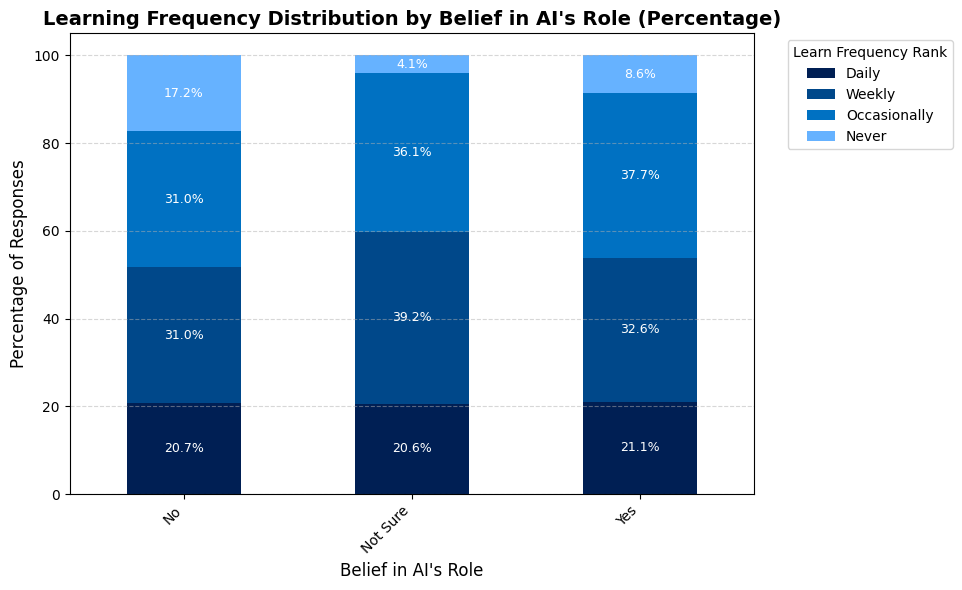

In [ ]:
# Calculate the proportion of each category in 'Learn_Frequency_Rank' for each AI belief group
frequency_counts = pd.crosstab(
    df["AI Key Role in CS Education Future"],
    df["Learn_Frequency_Rank"]
)

# Convert to percentages
frequency_percentages = frequency_counts.div(frequency_counts.sum(axis=1), axis=0) * 100

# Map rank values back to readable labels, in the order the columns actually appear
rank_to_label = {1: "Daily", 2: "Weekly", 3: "Occasionally", 5: "Never"}
legend_labels = [rank_to_label[r] for r in frequency_percentages.columns]

# Define the refined navy gradient colormap
custom_navy_gradient = LinearSegmentedColormap.from_list(
    "custom_navy_gradient",
     ["#001F54", "#003C7D", "#0061A5", "#0079D1", "#66B2FF"]  # Variations of #001A6E
)

# Plotting the stacked bar chart with the refined navy shades
plt.figure(figsize=(10, 6))
ax = frequency_percentages.plot(
    kind='bar',
    stacked=True,
    colormap=custom_navy_gradient,
    figsize=(10, 6),
    edgecolor=None  # Removed the border
)

# Adding percentages on top of each stack
for bar_group in ax.patches:
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"  # White text for clear visibility
        )

# Adding labels and title
plt.title("Learning Frequency Distribution by Belief in AI's Role (Percentage)", fontsize=14, fontweight="bold")
plt.xlabel("Belief in AI's Role", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(
    title="Learn Frequency Rank",
    labels=legend_labels,
    loc='upper right',
    bbox_to_anchor=(1.3, 1),
    fontsize=10
)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
df["Time Spent Solving a Programming Assignment"].unique()

array(['2–5 hours', 'More than 5 hours', 'Less than 2 hours'],
      dtype=object)

In [ ]:
time_mapping = {"Less than 2 hours": 1, "2–5 hours": 2, "More than 5 hours": 3}
df["Time_Rank"] = df["Time Spent Solving a Programming Assignment"].map(time_mapping)

difficulty_mapping = {"Easy": 1, "Moderate": 2, "Hard": 3}
df["Difficulty_Rank"] = df["Difficulty Rating of Programming Assignments"].map(difficulty_mapping)

# 2. Is there a correlation between the time spent on assignments and the perceived difficulty?
if not df["Time_Rank"].isna().any() and not df["Difficulty_Rank"].isna().any():
    correlation, p_value = stats.spearmanr(df["Time_Rank"], df["Difficulty_Rank"])
    print(f"Spearman's Correlation: Rho={correlation}, p-value={p_value}")
    if p_value < 0.05:
        print("Reject the null hypothesis: Significant correlation between time and difficulty.")
    else:
        print("Fail to reject the null hypothesis: No significant correlation.")
else:
    print("Missing data for correlation analysis.")

Spearman's Correlation: Rho=0.02231501612642305, p-value=0.6186306309247757
Fail to reject the null hypothesis: No significant correlation.


/tmp/ipykernel_1816/2567447851.py:25: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(


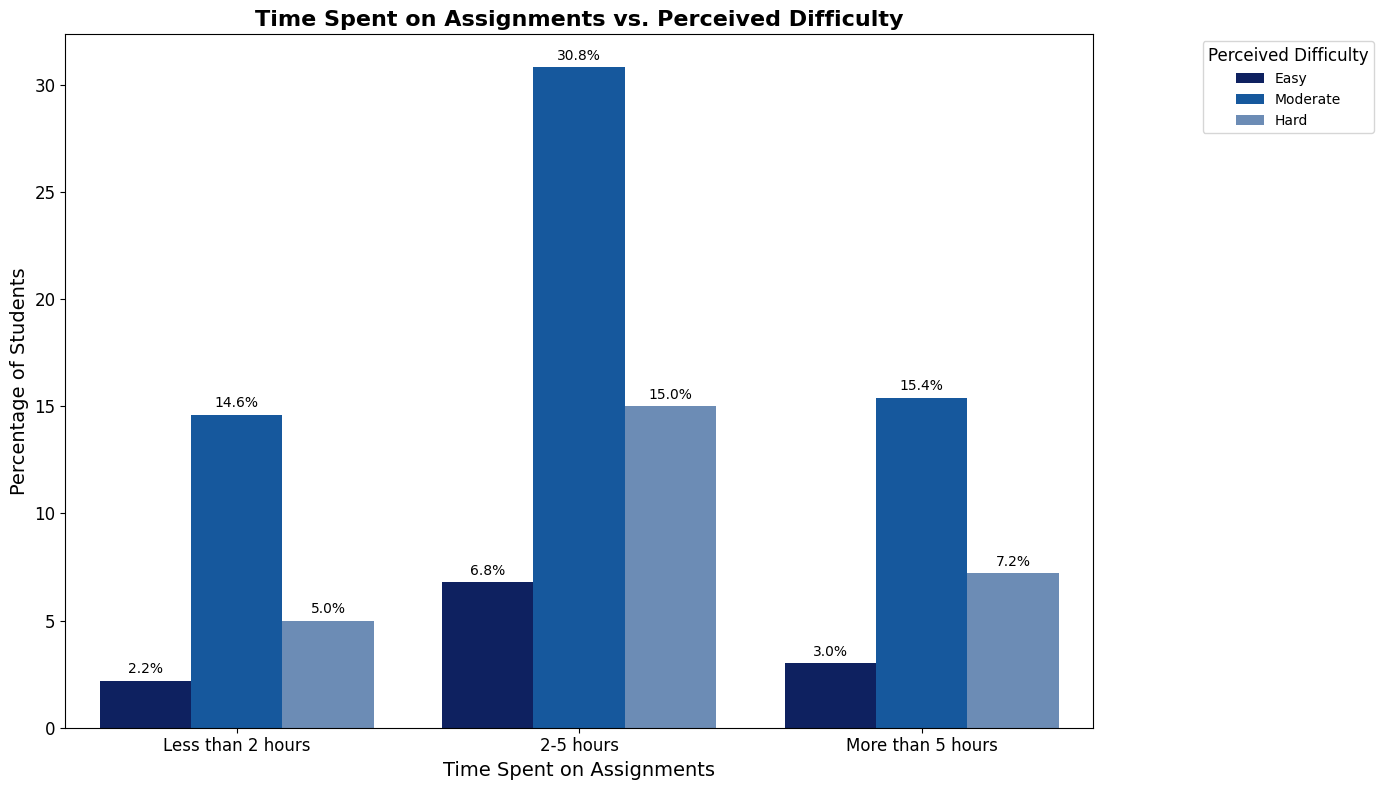

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already defined with the necessary data
time_labels = {1: "Less than 2 hours", 2: "2-5 hours", 3: "More than 5 hours"}
difficulty_labels = {1: "Easy", 2: "Moderate", 3: "Hard"}

# Group data by 'Time_Rank' and 'Difficulty_Rank', then calculate the count
grouped_data = df[["Time_Rank", "Difficulty_Rank"]].dropna().groupby(["Time_Rank", "Difficulty_Rank"]).size().reset_index(name="count")

# Map labels to make the data more interpretable
grouped_data["Time_Label"] = grouped_data["Time_Rank"].map(time_labels)
grouped_data["Difficulty_Label"] = grouped_data["Difficulty_Rank"].map(difficulty_labels)

# Calculate the percentage for each group relative to the total count
total_count = grouped_data["count"].sum()
grouped_data["Percentage"] = (grouped_data["count"] / total_count) * 100

# Define an improved custom navy blue color palette with better distinction
navy_blue_palette = ["#001A6E", "#0057B3", "#608BC1", "#00459F", "#002578"]

# Set up the plot with the new palette
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=grouped_data,
    x="Time_Label",
    y="Percentage",  # Use Percentage instead of count
    hue="Difficulty_Label",
    palette=navy_blue_palette,  # Apply the updated palette
)

# Add text labels (percentage) on top of each bar with some padding
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            # Get label text
            label = f"{height:.1f}%"  # Show only percentage
            # Adjust vertical padding to prevent the text from going out of bounds
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.2,  # Increase padding here if needed
                label,
                ha="center",
                va="bottom",
                color="black",  # Label color to make it visible
                fontsize=10,
            )

# Customize the chart
plt.title("Time Spent on Assignments vs. Perceived Difficulty", fontsize=16, fontweight="bold")
plt.xlabel("Time Spent on Assignments", fontsize=14)
plt.ylabel("Percentage of Students", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Adjust legend placement and styling
plt.legend(
    title="Perceived Difficulty",
    title_fontsize=12,
    loc="upper left",  # Adjusted to upper left
    bbox_to_anchor=(1.1, 1),
)

# Use tight_layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
print(df["Time_Rank"].value_counts())
print(df["Difficulty_Rank"].value_counts())


Time_Rank
2    263
3    128
1    109
Name: count, dtype: int64
Difficulty_Rank
2    304
3    136
1     60
Name: count, dtype: int64


In [ ]:
# 3. Does the use of AI tools inspire students to explore programming concepts beyond their curriculum?
contingency_table = pd.crosstab(
    df["Frequency of Using AI Tools for Assignments"],
    df["AI Inspired Exploration Beyond Curriculum"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Inspiration): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and inspiration.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Inspiration): Chi2=1.142350468340101, p-value=0.887495934895471
Fail to reject the null hypothesis: No significant association.


<Figure size 1200x600 with 0 Axes>

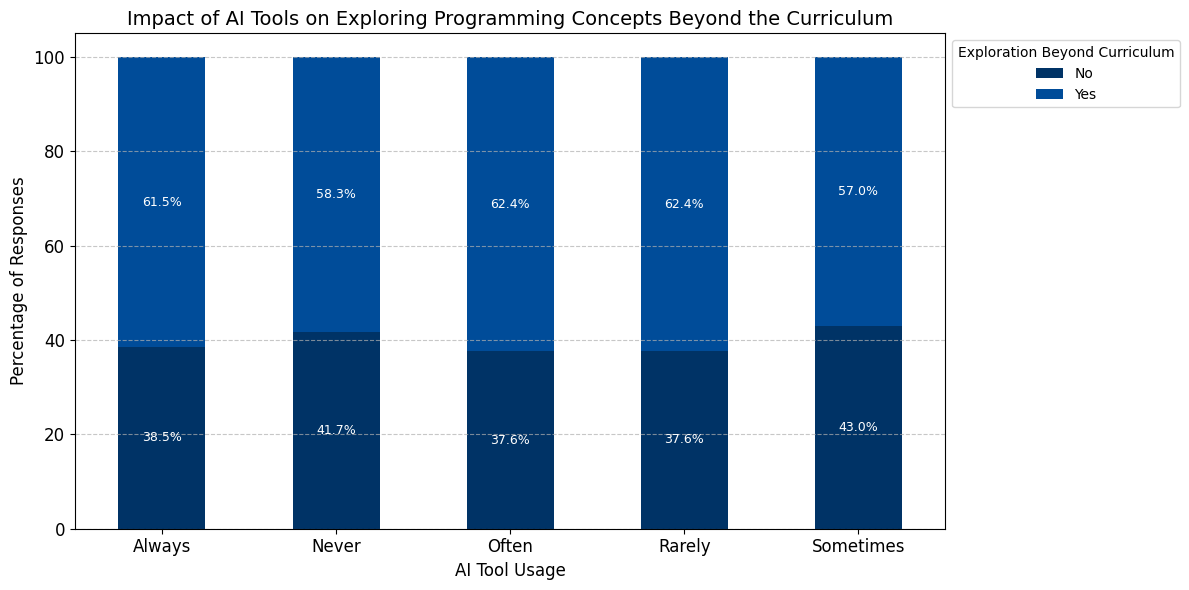

In [ ]:
# Calculate the percentage for each cell in the contingency table
contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Define a custom blue color palette
custom_palette = [
    "#003366", "#004C99", "#0066CC", "#3399FF", "#66CCFF", "#99CCFF", "#B3D1FF"
]

# Plotting the stacked bar chart with a custom color palette
plt.figure(figsize=(12, 6))
contingency_percentage.plot(kind='bar', stacked=True, color=custom_palette, figsize=(12, 6))

# Adding percentages on top of each stack
for i, bar_group in enumerate(plt.gca().patches):
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"
        )

# Adding labels and title
plt.title("Impact of AI Tools on Exploring Programming Concepts Beyond the Curriculum", fontsize=14)
plt.xlabel("AI Tool Usage", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Exploration Beyond Curriculum", loc="upper left", bbox_to_anchor=(1, 1))

# Adjust layout to avoid overlap
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
# 4. Do students who use AI tools perceive that these tools improve their problem-solving skills?
contingency_table = pd.crosstab(
    df["Frequency of Using AI Tools for Assignments"],
    df["AI Tools Improving Problem-Solving Skills"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Problem-Solving Skills): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Problem-Solving Skills): Chi2=5.943937978643428, p-value=0.6535117316676529
Fail to reject the null hypothesis: No significant association.


Chi-square Test (Problem-Solving Skills): Chi2=5.943937978643428, p-value=0.6535117316676529
Fail to reject the null hypothesis: No significant association.


<Figure size 1200x600 with 0 Axes>

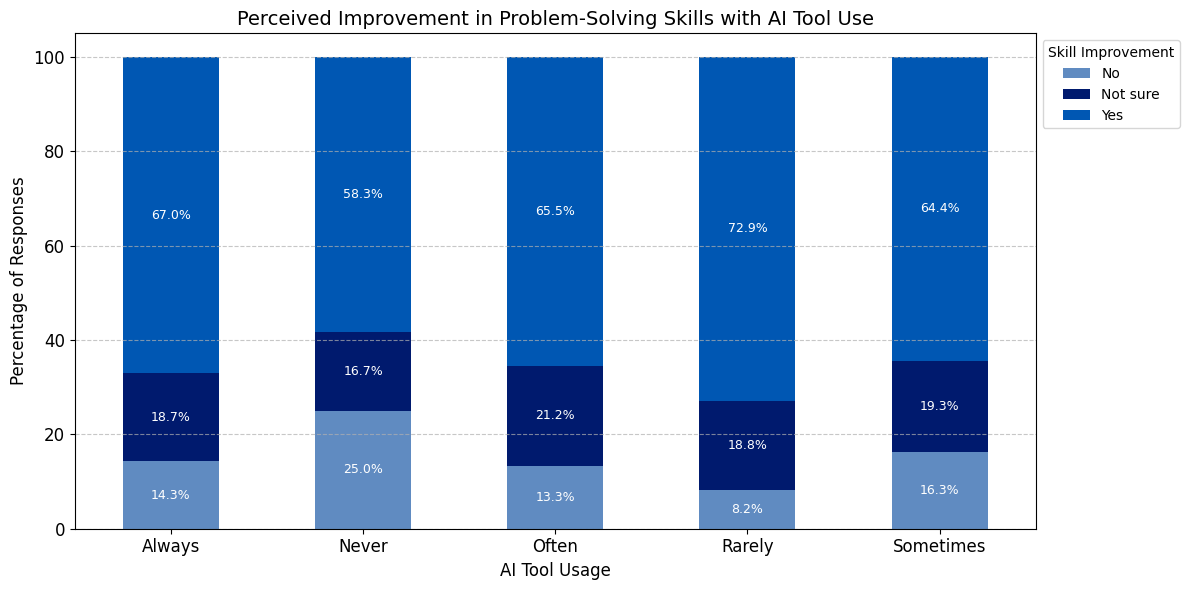

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Assuming 'df' is already loaded with your data

# Creating a contingency table
contingency_table = pd.crosstab(
    df["Frequency of Using AI Tools for Assignments"],
    df["AI Tools Improving Problem-Solving Skills"]
)

# Performing Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Problem-Solving Skills): Chi2={chi2}, p-value={p_value}")

# Displaying whether the null hypothesis is rejected or not
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between AI tool use and perceived skill improvement.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

# Calculating percentage distribution for plotting
contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

# Defining a custom color palette (for contrast and better visibility)
custom_palette = ["#608BC1", "#001A6E", "#0057B3"]

# Plotting the stacked bar chart with a custom color palette
plt.figure(figsize=(12, 6))
contingency_percentage.plot(kind='bar', stacked=True, color=custom_palette, figsize=(12, 6))

# Adding percentages on top of each stack
for bar_group in plt.gca().patches:
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color="white"
        )

# Adding labels and title
plt.title("Perceived Improvement in Problem-Solving Skills with AI Tool Use", fontsize=14)
plt.xlabel("AI Tool Usage", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Skill Improvement", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
# 5. Are there gender differences in the frequency of AI tool usage for programming assignments?

usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
gender_mapping = {"Male": 1, "Female": 2, "Other": 3}

df["Usage_Frequency_Rank"] = df["Frequency of Using AI Tools for Assignments"].map(usage_mapping)
df["Gender_Rank"] = df["Gender"].map(gender_mapping)

groups = [
    df[df["Gender_Rank"] == group]["Usage_Frequency_Rank"].dropna()
    for group in df["Gender_Rank"].unique()
]
if len(groups) > 1:
    stat, p_value = stats.kruskal(*groups)
    print(f"Kruskal-Wallis Test (Gender Differences): Stat={stat}, p-value={p_value}")
    if p_value < 0.05:
        print("Reject the null hypothesis: Significant difference in AI tool usage frequency by gender.")
    else:
        print("Fail to reject the null hypothesis: No significant difference in usage frequency by gender.")
else:
    print("Insufficient groups for Kruskal-Wallis Test.")

Kruskal-Wallis Test (Gender Differences): Stat=0.007821883893781283, p-value=0.929525845800732
Fail to reject the null hypothesis: No significant difference in usage frequency by gender.


/tmp/ipykernel_1816/912236695.py:16: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.countplot(data=df1, x='Learn_Frequency_Rank', hue='Gender', order=['Never', 'Rarely', 'Occasionally', 'Frequently', 'Always'], palette=navy_palette)


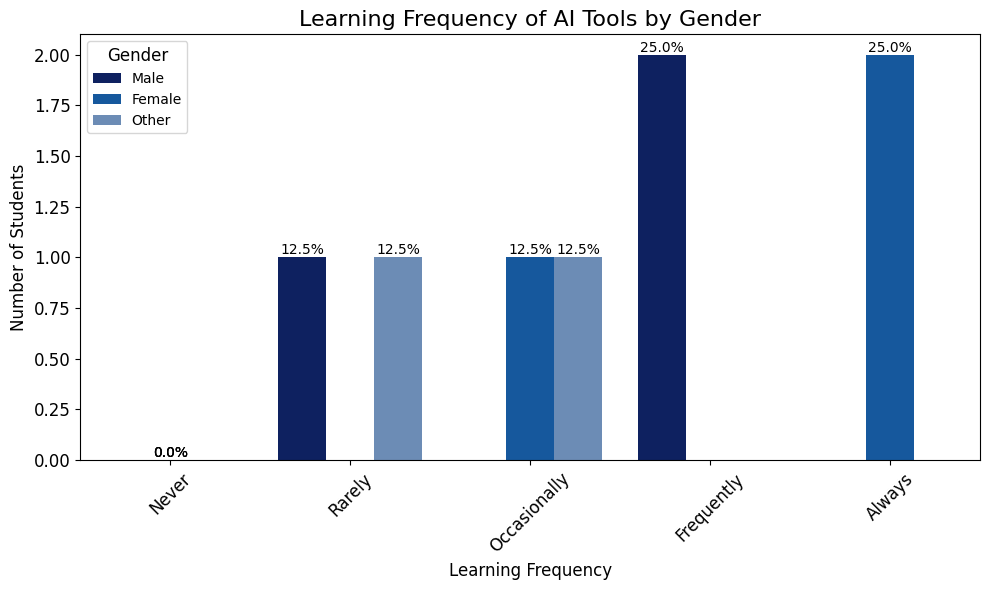

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame (replace with your actual data)
df1 = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Other', 'Female', 'Male', 'Other'],
    'Learn_Frequency_Rank': ['Frequently', 'Always', 'Occasionally', 'Frequently', 'Rarely', 'Always', 'Rarely', 'Occasionally']
})

# Define a navy blue color palette
navy_palette = ["#001A6E", "#0057B3", "#608BC1", "#00459F", "#002578"]

# Plot the bar chart with hue for gender
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df1, x='Learn_Frequency_Rank', hue='Gender', order=['Never', 'Rarely', 'Occasionally', 'Frequently', 'Always'], palette=navy_palette)

# Add percentage labels on top of the bars
total = len(df1)  # Total number of data points
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f"{percentage:.1f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=10, color='black',
                xytext=(0, 5), textcoords='offset points')

# Customize the chart
plt.title("Learning Frequency of AI Tools by Gender", fontsize=16)
plt.xlabel("Learning Frequency", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Gender", title_fontsize=12, loc="upper left")

# Adjust layout to ensure no overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# 6. Are students who use AI tools primarily for assistance more likely to consider its use ethically acceptable?
contingency_table = pd.crosstab(
    df["Primary Use of AI Tools"],
    df["AI Tool Use Ethically Acceptable"]
)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Ethical Acceptability): Chi2={chi2}, p-value={p_value}")
if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between primary use and ethical acceptability.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

Chi-square Test (Ethical Acceptability): Chi2=0.5820412023610907, p-value=0.7475002784712725
Fail to reject the null hypothesis: No significant association.


Chi-square Test (Ethical Acceptability): Chi2=0.5820412023610907, p-value=0.7475002784712725
Fail to reject the null hypothesis: No significant association.


<Figure size 1200x600 with 0 Axes>

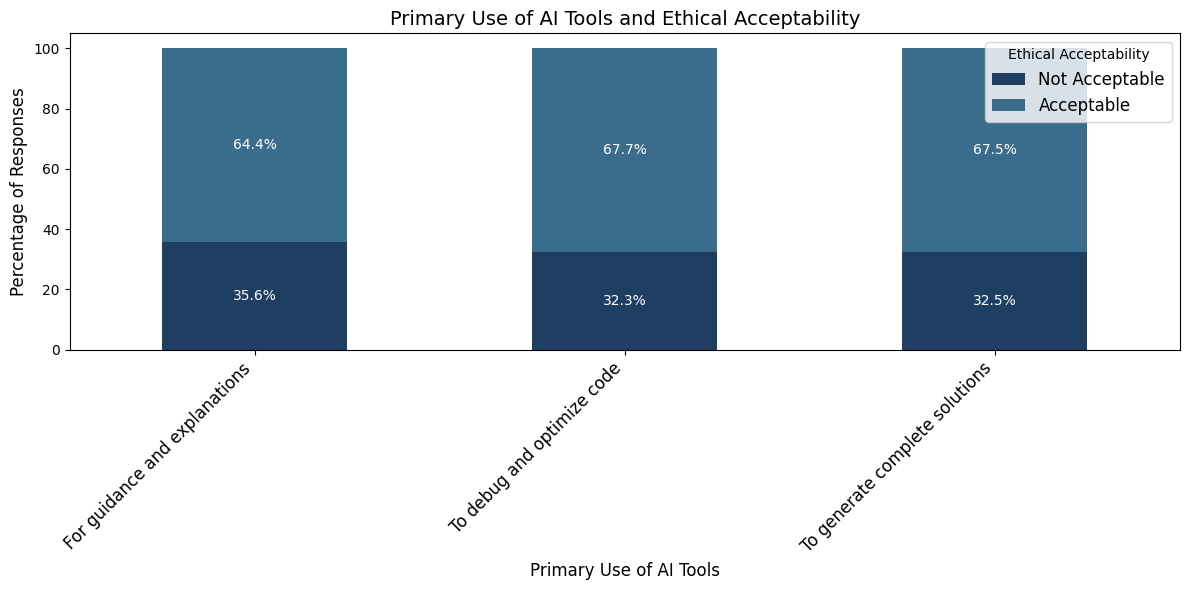

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Contingency table for primary use and ethical acceptability
contingency_table = pd.crosstab(
    df["Primary Use of AI Tools"],
    df["AI Tool Use Ethically Acceptable"]
)

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Test (Ethical Acceptability): Chi2={chi2}, p-value={p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: Significant association between primary use and ethical acceptability.")
else:
    print("Fail to reject the null hypothesis: No significant association.")

# Plotting the stacked bar chart with a custom color palette
plt.figure(figsize=(12, 6))

# Custom color palette that avoids the white color
custom_palette = ["#1E3E62", "#3A6D8C"]  # First color = "No", second = "Yes" (see note below)
contingency_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_percentage.plot(kind='bar', stacked=True, figsize=(12, 6), color=custom_palette)

# Adding percentage labels on top of each bar
for i, bar_group in enumerate(plt.gca().patches):
    height = bar_group.get_height()
    if height > 0:  # Avoid clutter with zero-height bars
        plt.text(
            bar_group.get_x() + bar_group.get_width() / 2,
            bar_group.get_y() + height / 2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            color="white"
        )

# Adding title and labels
plt.title("Primary Use of AI Tools and Ethical Acceptability", fontsize=14)
plt.xlabel("Primary Use of AI Tools", fontsize=12)
plt.ylabel("Percentage of Responses", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.legend(title="Ethical Acceptability", labels=["Not Acceptable", "Acceptable"], fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Map AI reliance and perceived negative impacts to ranks
ai_usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
impact_mapping = {"Yes": 1, "No": 2, "Unsure": 3}

df["AI_Reliance_Rank"] = df["Frequency of Using AI Tools for Assignments"].map(ai_usage_mapping)
df["Negative_Impact_Rank"] = df["AI Reliance May Negatively Affect Long-term Programming Skills"].map(impact_mapping)

# Handle missing values
df = df.dropna(subset=["AI_Reliance_Rank", "Negative_Impact_Rank"])

# Check unique values
print("AI_Reliance_Rank unique values:", df["AI_Reliance_Rank"].unique())
print("Negative_Impact_Rank unique values:", df["Negative_Impact_Rank"].unique())

# Spearman's Correlation
correlation, p_value = stats.spearmanr(df["AI_Reliance_Rank"], df["Negative_Impact_Rank"])
print(f"Spearman's Correlation: Rho={correlation}, p-value={p_value}")

AI_Reliance_Rank unique values: [4 5 2 3 1]
Negative_Impact_Rank unique values: [1 3 2]
Spearman's Correlation: Rho=-0.0518830666413073, p-value=0.2468571026140623


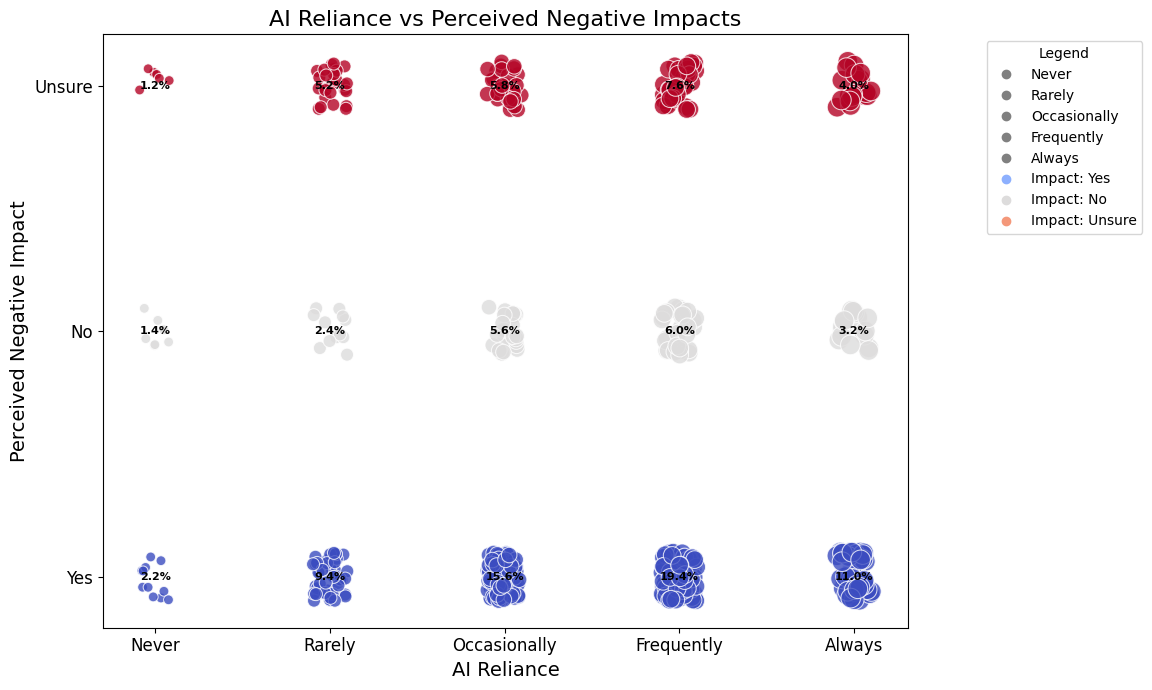

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Jitter to avoid overlapping points
jittered_ai_reliance = df["AI_Reliance_Rank"] + np.random.uniform(-0.1, 0.1, size=len(df))
jittered_negative_impact = df["Negative_Impact_Rank"] + np.random.uniform(-0.1, 0.1, size=len(df))

# Define label mappings
ai_reliance_labels = {1: "Never", 2: "Rarely", 3: "Occasionally", 4: "Frequently", 5: "Always"}
negative_impact_labels = {1: "Yes", 2: "No", 3: "Unsure"}

# Create the scatter plot
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    x=jittered_ai_reliance,
    y=jittered_negative_impact,
    hue=df["Negative_Impact_Rank"],
    palette="coolwarm",
    size=df["AI_Reliance_Rank"],
    sizes=(50, 200),  # Increased marker sizes
    alpha=0.8,  # Slightly more opaque markers
    legend=False  # Disable default legend to create a custom one
)

# Annotate percentages
contingency_table = pd.crosstab(
    df["AI_Reliance_Rank"],
    df["Negative_Impact_Rank"],
    normalize="all"
) * 100

for ai_rank, row in contingency_table.iterrows():
    for impact_rank, percentage in row.items():
        if percentage > 0:  # Only annotate non-zero percentages
            plt.text(
                x=ai_rank,
                y=impact_rank,
                s=f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                weight="bold"  # Bold text for better visibility
            )

# Customize plot
plt.title("AI Reliance vs Perceived Negative Impacts", fontsize=16)
plt.xlabel("AI Reliance", fontsize=14)
plt.ylabel("Perceived Negative Impact", fontsize=14)

# Update tick labels
plt.xticks(ticks=range(1, 6), labels=ai_reliance_labels.values(), fontsize=12)
plt.yticks(ticks=range(1, 4), labels=negative_impact_labels.values(), fontsize=12)

# Add a custom legend
ai_reliance_legend = [
    Line2D([0], [0], marker='o', color='gray', label=label, linestyle='', markerfacecolor='gray', markersize=6)
    for label in ai_reliance_labels.values()
]

negative_impact_legend = [
    Line2D([0], [0], marker='o', color=color, label=f"Impact: {label}", linestyle='', markersize=6)
    for color, label in zip(sns.color_palette("coolwarm", n_colors=3), negative_impact_labels.values())
]

# Combine legends
plt.legend(
    handles=ai_reliance_legend + negative_impact_legend,
    title="Legend",
    title_fontsize=10,
    fontsize=10,
    loc="upper right",
    bbox_to_anchor=(1.3, 1)
)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# Kruskal-Wallis Test
groups = [
    df[df["AI_Reliance_Rank"] == rank]["Negative_Impact_Rank"]
    for rank in df["AI_Reliance_Rank"].unique()
]
if len(groups) > 1:  # Ensure there are at least two groups
    stat, p_value = stats.kruskal(*groups)
    print(f"Kruskal-Wallis Test: Stat={stat}, p-value={p_value}")
else:
    print("Kruskal-Wallis Test cannot be performed: Only one group present.")

Kruskal-Wallis Test: Stat=1.9674474347390203, p-value=0.7417463255645486


Class balance:
 Negative_Impact_Label
1.0    290
0.0    142
Name: count, dtype: int64
Accuracy: 0.7011494252873564
Classification Report:
               precision    recall  f1-score   support

         0.0       0.54      0.69      0.61        29
         1.0       0.82      0.71      0.76        58

    accuracy                           0.70        87
   macro avg       0.68      0.70      0.68        87
weighted avg       0.73      0.70      0.71        87



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


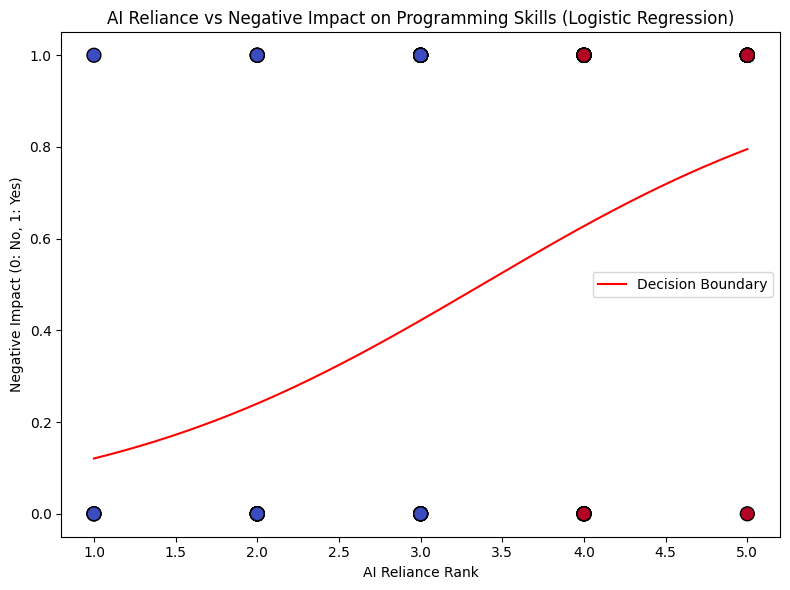

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
file_path = "/content/drive/MyDrive/smm/AI_Programming_Assignments_Survey_Synthetic_500 (1).csv"
df = pd.read_csv(file_path)

# Preprocessing
ai_usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
impact_mapping = {"Yes": 1, "No": 0}  # "Unsure" dropped -> binary target

df["AI_Reliance_Rank"] = df["Frequency of Using AI Tools for Assignments"].map(ai_usage_mapping)
df["Negative_Impact_Label"] = df["AI Reliance May Negatively Affect Long-term Programming Skills"].map(impact_mapping)

# Drop rows with missing values (this now also drops "Unsure" rows, since they map to NaN)
df = df.dropna(subset=["AI_Reliance_Rank", "Negative_Impact_Label"])

print("Class balance:\n", df["Negative_Impact_Label"].value_counts())

# Features and target
X = df[["AI_Reliance_Rank"]]
y = df["Negative_Impact_Label"]

# Split the data (stratify to keep class balance similar in train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train logistic regression model
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, c=y_pred, cmap="coolwarm", edgecolors='k', s=100)

x_range = np.linspace(X["AI_Reliance_Rank"].min(), X["AI_Reliance_Rank"].max(), 300)
y_range = model.predict_proba(x_range.reshape(-1, 1))[:, 1]
plt.plot(x_range, y_range, color="red", label="Decision Boundary")

plt.xlabel("AI Reliance Rank")
plt.ylabel("Negative Impact (0: No, 1: Yes)")
plt.title("AI Reliance vs Negative Impact on Programming Skills (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Columns for AI reliance and perceived negative impact
ai_usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
impact_mapping = {"Yes": 1, "No": 0, "Unsure": 2}

# Map the categorical values to numerical ranks
df["AI_Reliance_Rank"] = df["Frequency of Using AI Tools for Assignments"].map(ai_usage_mapping)
df["Negative_Impact_Label"] = df["AI Reliance May Negatively Affect Long-term Programming Skills"].map(impact_mapping)

# Drop rows with missing values in the relevant columns
df = df.dropna(subset=["AI_Reliance_Rank", "Negative_Impact_Label"])

# Create groups based on AI reliance rank
# Group by AI reliance rank, with each group corresponding to different levels of reliance
ranks = sorted(df["AI_Reliance_Rank"].unique())
groups = [df[df["AI_Reliance_Rank"] == rank]["Negative_Impact_Label"] for rank in ranks]

# Debug: Check group counts
for rank, group in zip(ranks, groups):
    print(f"Group (AI Reliance Rank {rank}) Count: {group.count()}")

# Perform ANOVA (if there are at least two groups)
if len(groups) > 1:
    f_stat, p_value = f_oneway(*groups)
    print("F-statistic:", f_stat)
    print("p-value:", p_value)

    # Decision based on p-value
    if p_value < 0.05:
        print("Reject H0: Significant difference in perceived negative impact based on AI reliance.")
    else:
        print("Fail to reject H0: No significant difference in perceived negative impact based on AI reliance.")
else:
    print("ANOVA cannot be performed: Only one group present.")

Group (AI Reliance Rank 1) Count: 18
Group (AI Reliance Rank 2) Count: 64
Group (AI Reliance Rank 3) Count: 113
Group (AI Reliance Rank 4) Count: 150
Group (AI Reliance Rank 5) Count: 87
F-statistic: 21.76265247055965
p-value: 2.325996447228043e-16
Reject H0: Significant difference in perceived negative impact based on AI reliance.


F-statistic: 21.76265247055965
p-value: 2.325996447228043e-16
Reject H0: Significant difference in perceived negative impact based on AI reliance.


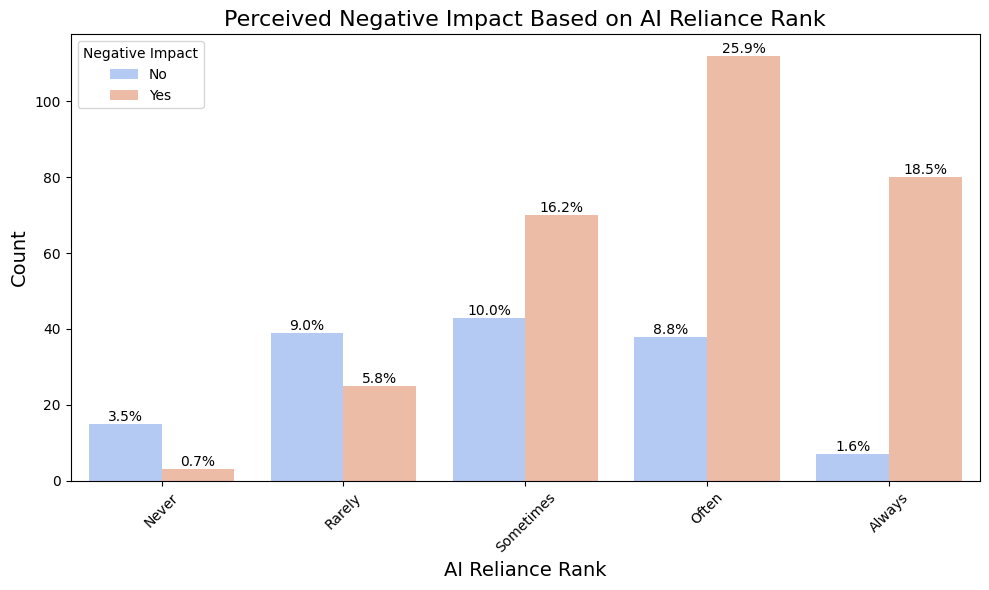

In [ ]:
# AI reliance and negative impact mapping
ai_usage_mapping = {"Never": 1, "Rarely": 2, "Sometimes": 3, "Often": 4, "Always": 5}
impact_mapping = {"Yes": 1, "No": 0, "Unsure": 2}

# Map the categorical values to numerical ranks
df["AI_Reliance_Rank"] = df["Frequency of Using AI Tools for Assignments"].map(ai_usage_mapping)
df["Negative_Impact_Label"] = df["AI Reliance May Negatively Affect Long-term Programming Skills"].map(impact_mapping)

# Drop rows with missing values in the relevant columns
df = df.dropna(subset=["AI_Reliance_Rank", "Negative_Impact_Label"])

# Create groups based on AI reliance rank
ranks = sorted(df["AI_Reliance_Rank"].unique())
groups = [df[df["AI_Reliance_Rank"] == rank]["Negative_Impact_Label"] for rank in ranks]

# Perform ANOVA
if len(groups) > 1:
    f_stat, p_value = f_oneway(*groups)
    print("F-statistic:", f_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("Reject H0: Significant difference in perceived negative impact based on AI reliance.")
    else:
        print("Fail to reject H0: No significant difference in perceived negative impact based on AI reliance.")
else:
    print("ANOVA cannot be performed: Only one group present.")

# Create a bar plot showing the distribution of perceived negative impact by AI reliance rank
plt.figure(figsize=(10, 6))
sns.countplot(x="AI_Reliance_Rank", hue="Negative_Impact_Label", data=df, palette="coolwarm")

# Add labels and percentages
total_responses = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_x(), p.get_y()
    if height > 0:
        percentage = f'{(height / total_responses) * 100:.1f}%'
        plt.text(x + width / 2, y + height, percentage, ha="center", va="bottom", fontsize=10)

# Set labels, title, and legend
plt.title("Perceived Negative Impact Based on AI Reliance Rank", fontsize=16)
plt.xlabel("AI Reliance Rank", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(ticks=range(5), labels=["Never", "Rarely", "Sometimes", "Often", "Always"], rotation=45)

# Fix legend to match actual hue order/labels seaborn assigns (sorted numeric: 0, 1, 2)
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["No", "Yes", "Unsure"], title="Negative Impact", loc="upper left")

plt.tight_layout()
plt.show()